In [1]:
import pandas as pd
import numpy as np

In [13]:
movie_df = pd.read_csv("ml-100k/u.item", sep='|', encoding='latin-1', header=None)

In [14]:
print(movie_df.shape)

(1682, 24)


In [15]:
movie_df.columns = [
    'movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

In [16]:
movie_content = movie_df[['movie_id', 'movie_title', 'Action', 'Adventure',
                          'Animation', "Children's", 'Comedy', 'Crime',
                          'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
                          'Horror', 'Musical', 'Mystery', 'Romance',
                          'Sci-Fi', 'Thriller', 'War', 'Western']]

In [30]:
genres = ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
          'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
          'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

top5_by_genre = {}

for genre in genres:
    top5 = movie_content[movie_content[genre] == 1]['movie_title'].head(5)
    top5_by_genre[genre] = top5.tolist()

for genre, movies in top5_by_genre.items():
    print(f"\nTop 5 {genre} movies:")
    for m in movies: print(m)


Top 5 Action movies:
GoldenEye (1995)
Get Shorty (1995)
From Dusk Till Dawn (1996)
Muppet Treasure Island (1996)
Braveheart (1995)

Top 5 Adventure movies:
GoldenEye (1995)
Muppet Treasure Island (1996)
Rumble in the Bronx (1995)
Batman Forever (1995)
Free Willy 2: The Adventure Home (1995)

Top 5 Animation movies:
Toy Story (1995)
Lion King, The (1994)
Aladdin (1992)
Snow White and the Seven Dwarfs (1937)
Heavy Metal (1981)

Top 5 Children's movies:
Toy Story (1995)
Babe (1995)
Free Willy 2: The Adventure Home (1995)
Santa Clause, The (1994)
Lion King, The (1994)

Top 5 Comedy movies:
Toy Story (1995)
Get Shorty (1995)
Babe (1995)
Mighty Aphrodite (1995)
French Twist (Gazon maudit) (1995)

Top 5 Crime movies:
Copycat (1995)
Seven (Se7en) (1995)
Usual Suspects, The (1995)
From Dusk Till Dawn (1996)
Rumble in the Bronx (1995)

Top 5 Documentary movies:
Crumb (1994)
Hoop Dreams (1994)
Brother Minister: The Assassination of Malcolm X (1994)
Haunted World of Edward D. Wood Jr., The (1995)

In [20]:
# count how many genres each movie belongs to
movie_content['genre_count'] = movie_content.iloc[:, 2:].sum(axis=1)

# sort and get top 5
top5_overall = movie_content.sort_values(by='genre_count', ascending=False)['movie_title'].head(5)

print("\nTop 5 Overall Movies:")
print(top5_overall.tolist())


Top 5 Overall Movies:
['Transformers: The Movie, The (1986)', "Kid in King Arthur's Court, A (1995)", 'Empire Strikes Back, The (1980)', 'Space Jam (1996)', 'From Dusk Till Dawn (1996)']


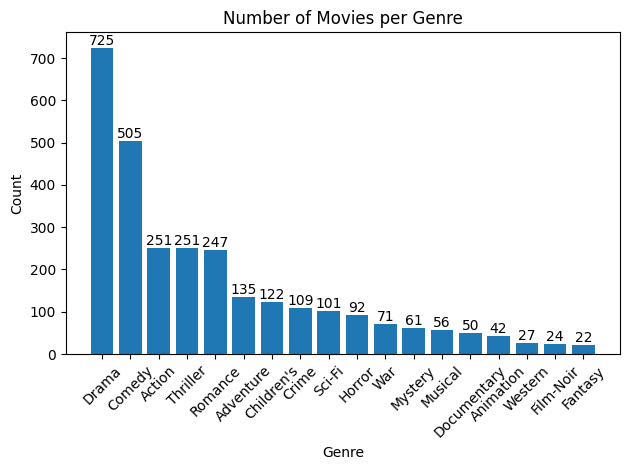

In [33]:
movie_content = movie_content.drop(columns=['genre_count'])

import matplotlib.pyplot as plt

genre_counts = movie_content.iloc[:, 2:].sum().sort_values(ascending=False)

plt.figure()
bars = plt.bar(genre_counts.index, genre_counts.values)

# Add labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, int(height), ha='center', va='bottom')

plt.title("Number of Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

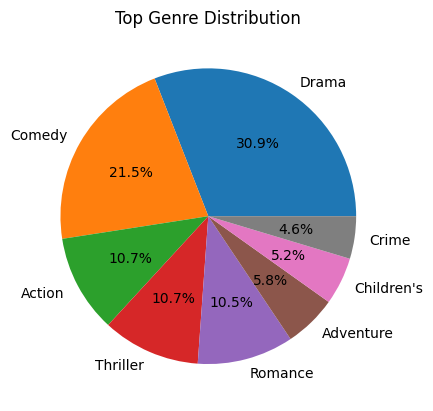

In [34]:
genre_counts.head(8).plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Genre Distribution")
plt.ylabel("")
plt.show()

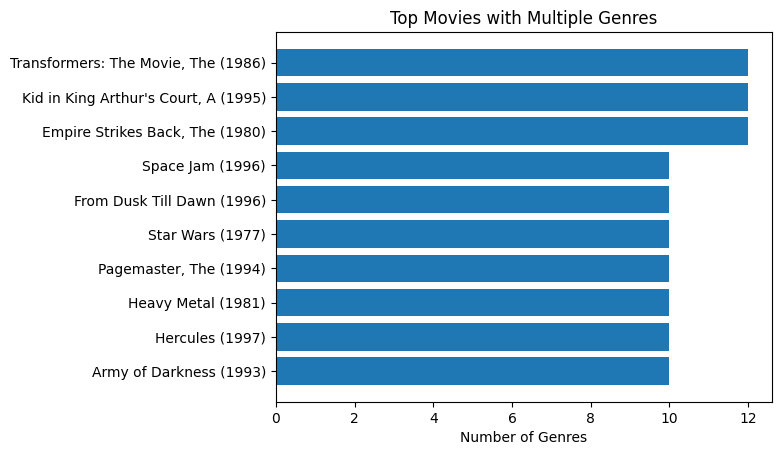

In [27]:
movie_content['genre_count'] = movie_content.iloc[:, 2:].sum(axis=1)

top_movies = movie_content.sort_values(by='genre_count', ascending=False).head(10)

plt.barh(top_movies['movie_title'], top_movies['genre_count'])
plt.title("Top Movies with Multiple Genres")
plt.xlabel("Number of Genres")
plt.gca().invert_yaxis()
plt.show()

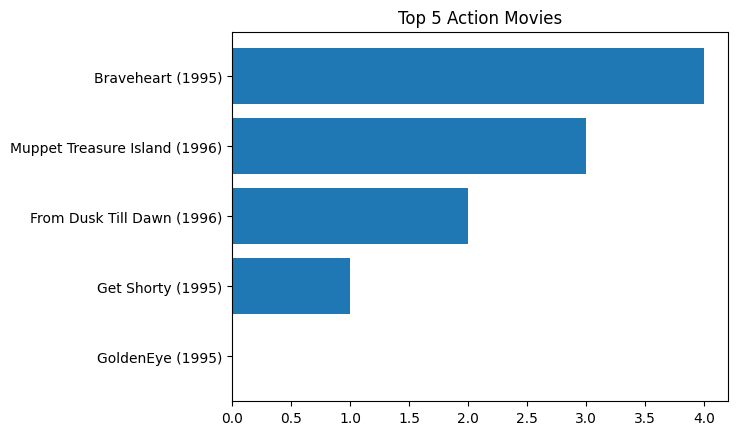

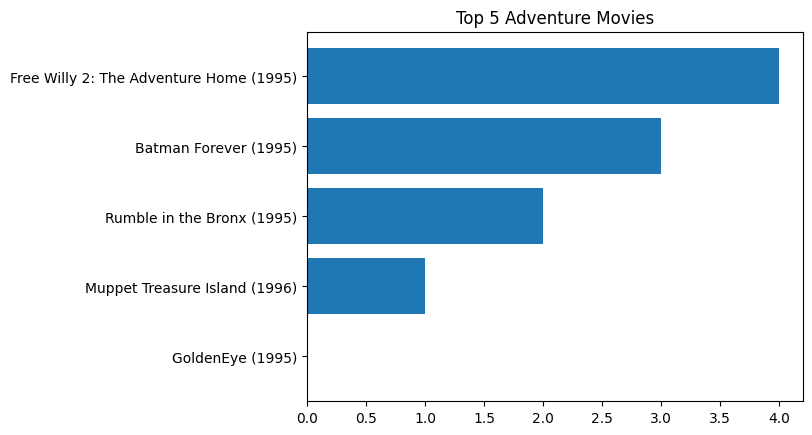

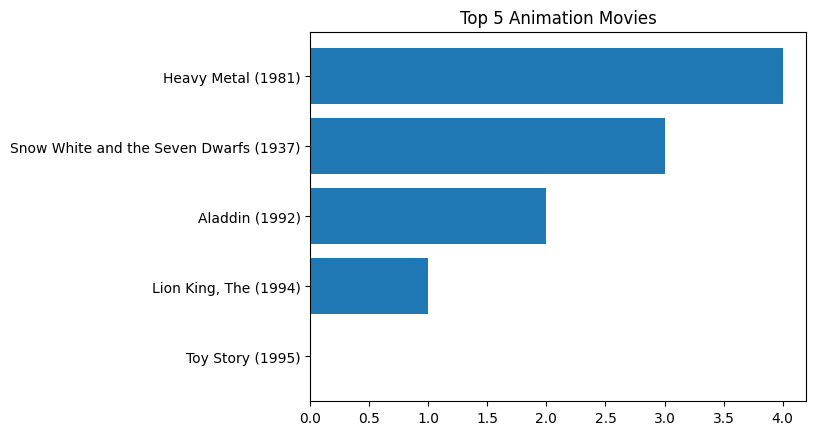

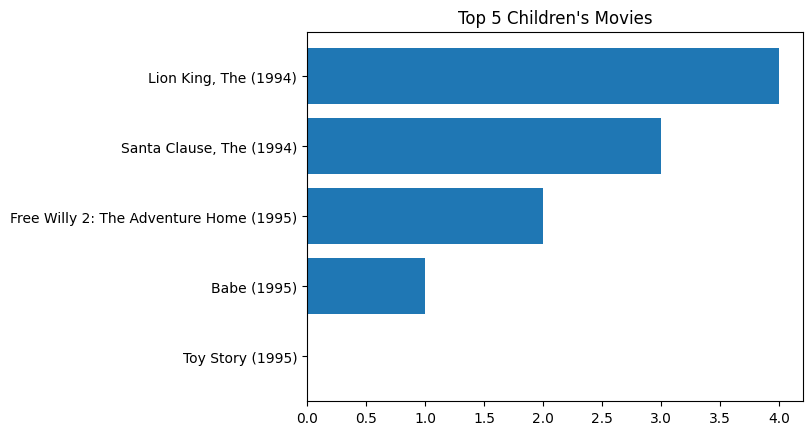

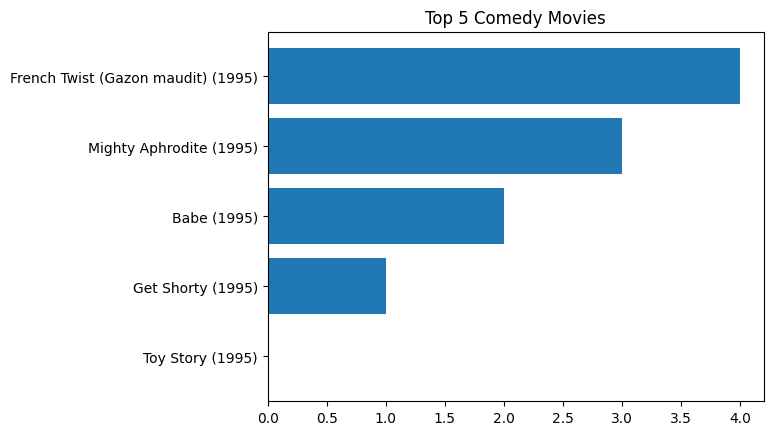

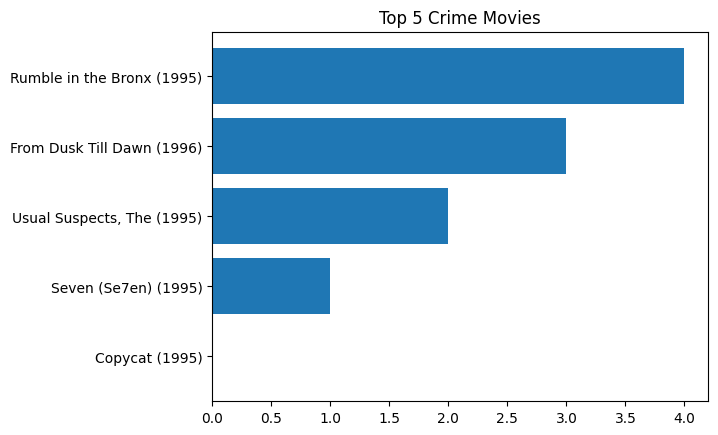

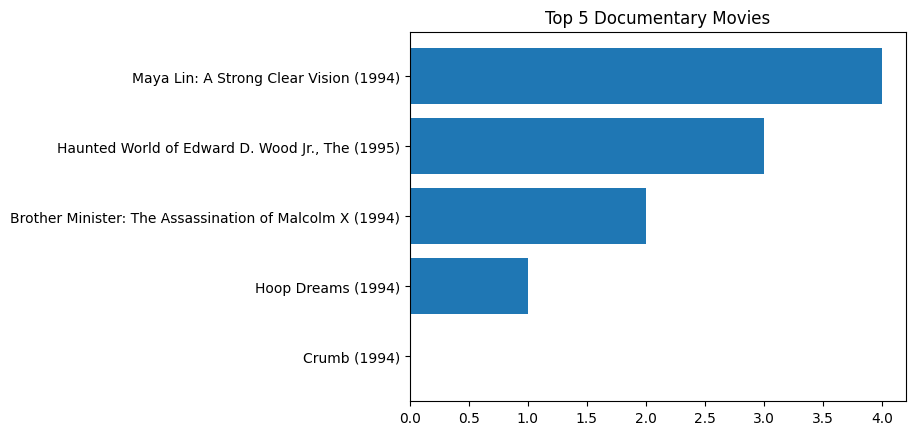

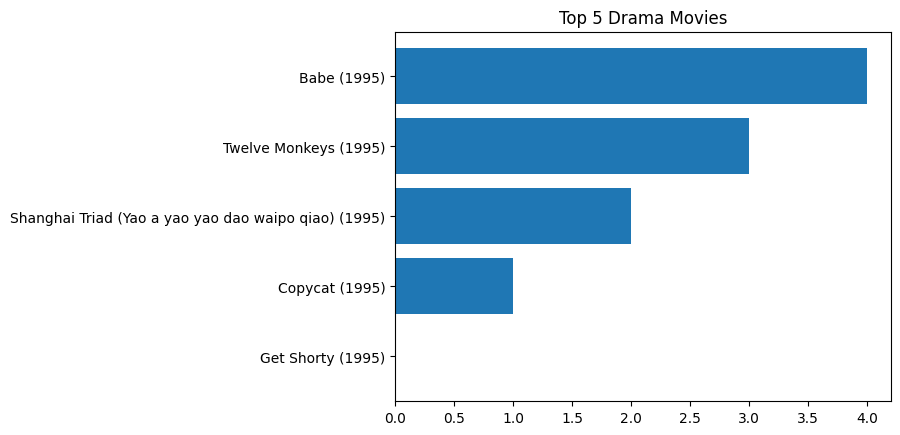

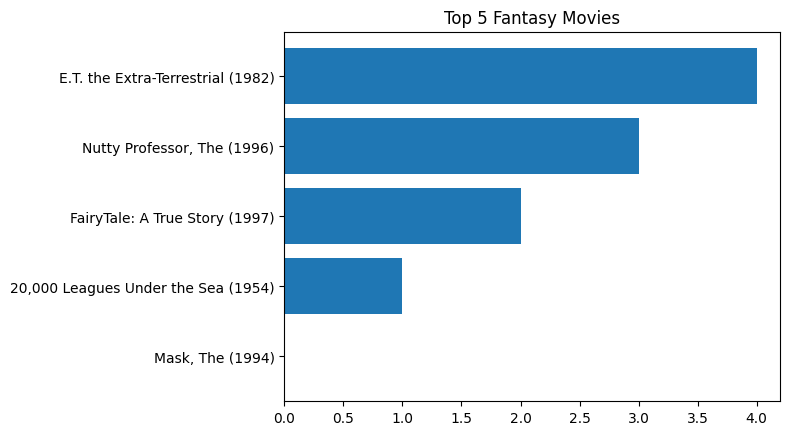

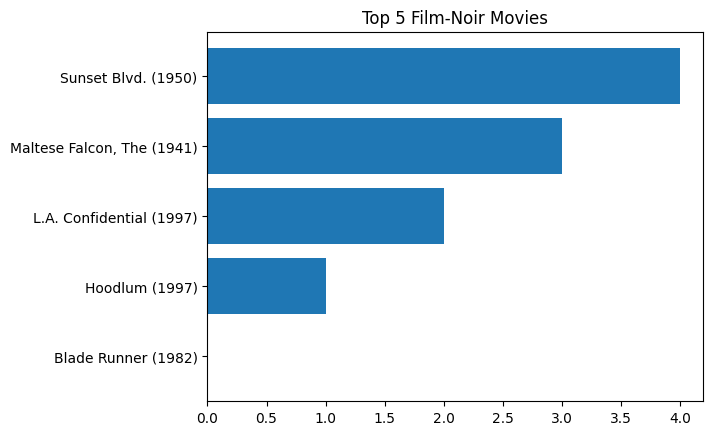

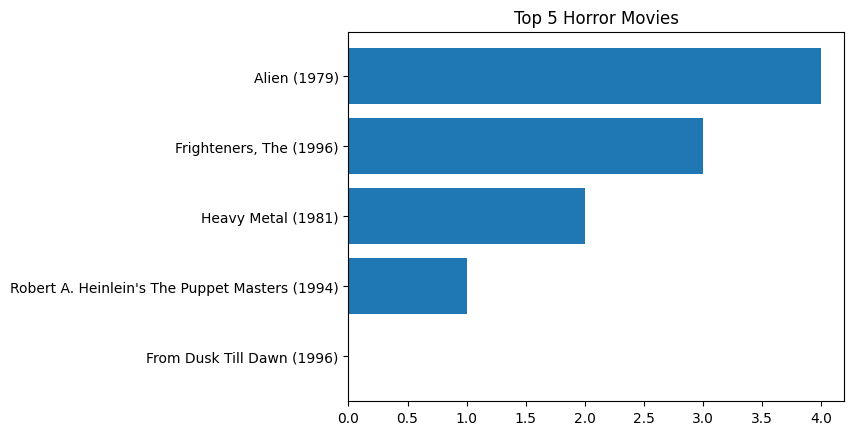

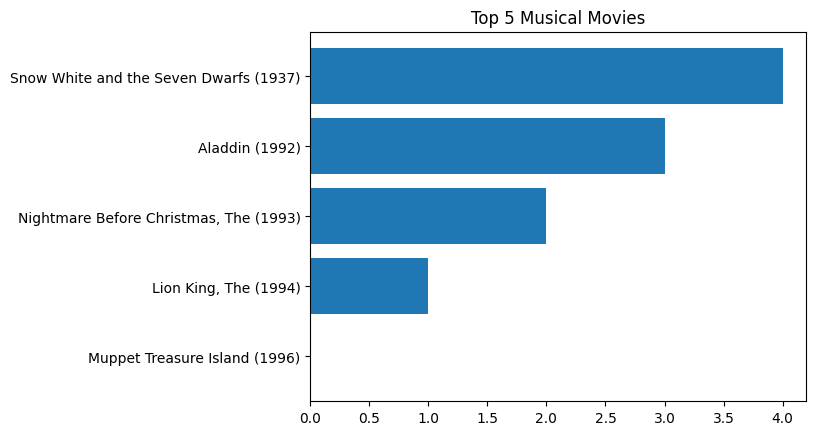

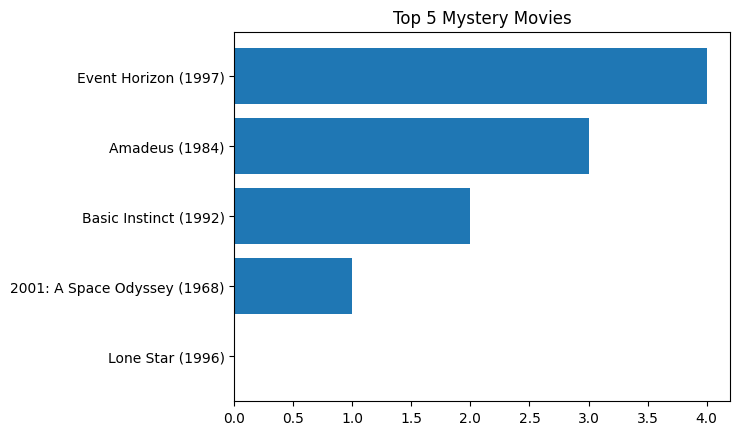

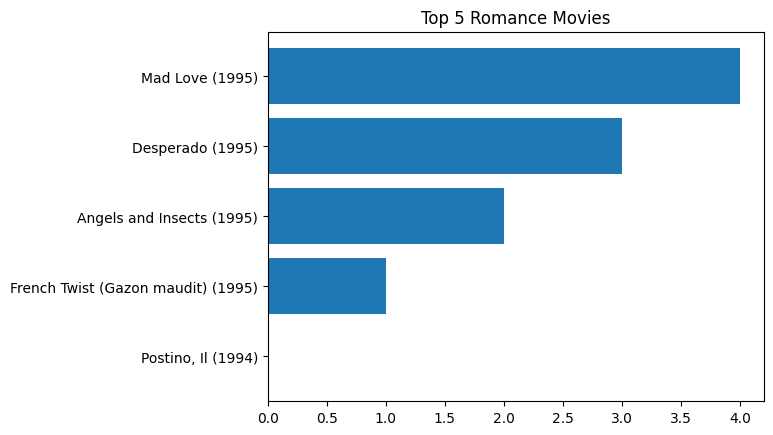

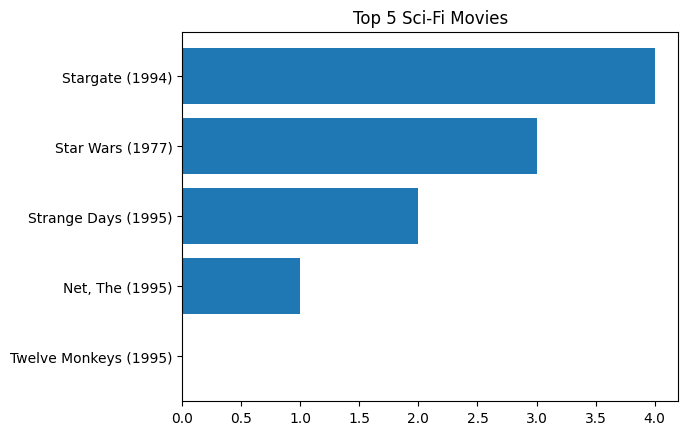

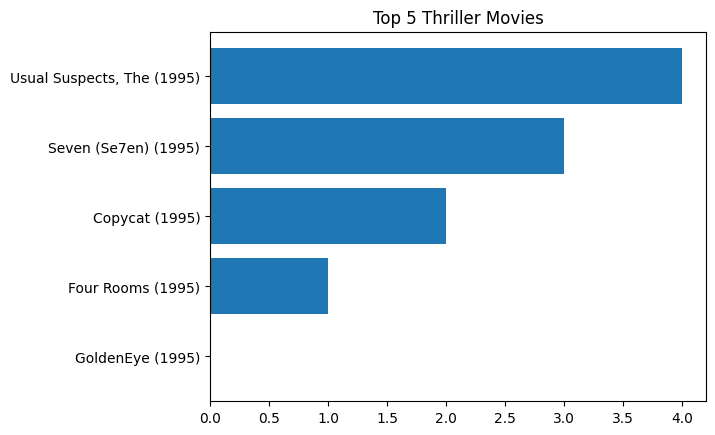

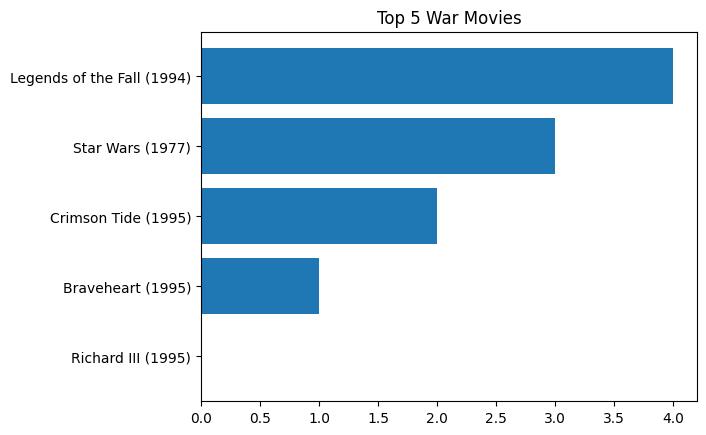

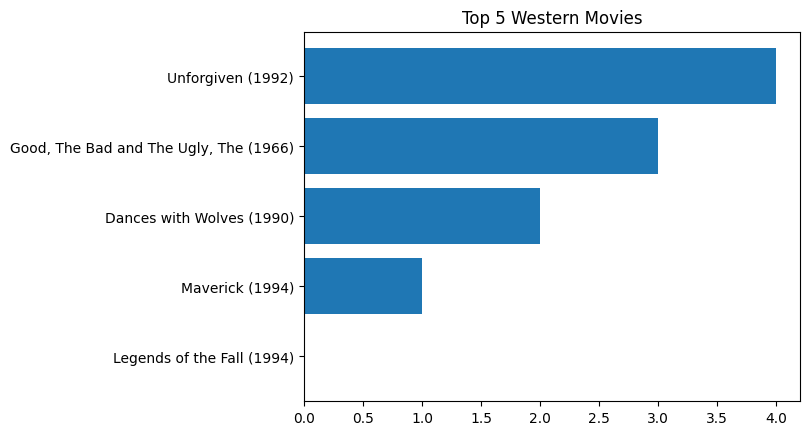

In [29]:
for genre in genres:
    top5 = movie_content[movie_content[genre] == 1]['movie_title'].head(5)
    
    plt.figure()
    plt.barh(top5, range(len(top5)))
    plt.title(f"Top 5 {genre} Movies")
    plt.show()